**Import Libraries**

In [178]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [179]:
df = pd.read_csv('Customer-Churn-Prediction.csv')  # import dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [180]:
df.shape

(7043, 21)

In [181]:
df2 = df.copy()
df3 = df.copy()
df1 = df.copy()

**Let's Go**

In [182]:
df.head()  # ISP company

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [183]:
df.shape

(7043, 21)

In [184]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [185]:
df['Churn'].value_counts()
# class imbalanced check by Churn features(yes/no)

,count
Churn,
No,5174
Yes,1869


In [186]:
#drop duplicates rows
df.drop_duplicates(inplace=True) # if duplicates vale are here than del

In [187]:
df.shape

(7043, 21)

In [188]:
# now check percentage wise to implance class(y/n)
not_churned = (5174/(5174+1869)) * 100
churned = (1869/(5174+1869)) * 100

print('Not churned {} percent of total people'.format(not_churned))
print('churned {} percent of total people'.format(churned))

Not churned 73.4630129206304 percent of total people
churned 26.536987079369588 percent of total people


<Axes: xlabel='count', ylabel='Churn'>

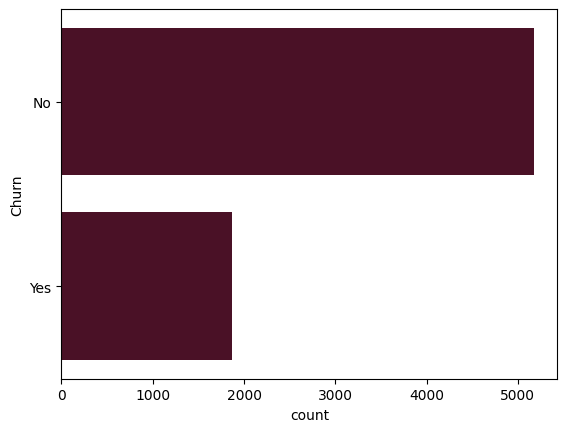

In [189]:
# now plot show class percentage.
sns.countplot(df['Churn'], color='#540723')

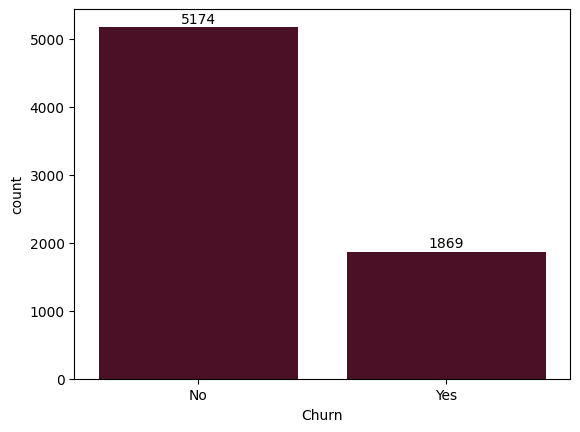

In [190]:
# top of the bar count's the number of class show
sns.countplot(x = df['Churn'], color='#540723')

for p in plt.gca().patches:
  plt.text(p.get_x() + p.get_width()/2,  #x-coordinate
           p.get_height() + 60,          # y-coordinate
           int(p.get_height()),          # the count value
           ha='center'                   # center aligment
           )

plt.show()

<Axes: xlabel='gender', ylabel='count'>

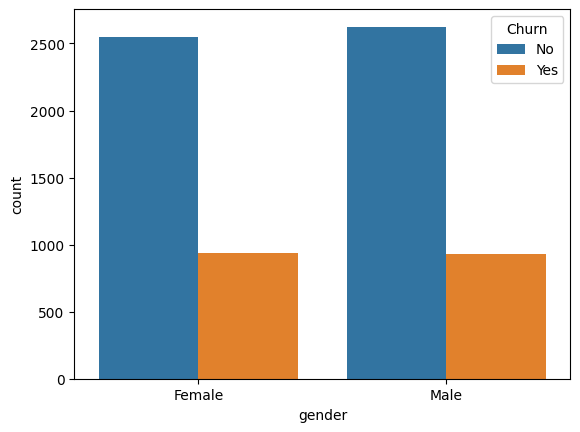

In [191]:
sns.countplot(x = 'gender', hue = 'Churn', data = df) # chrun is class column

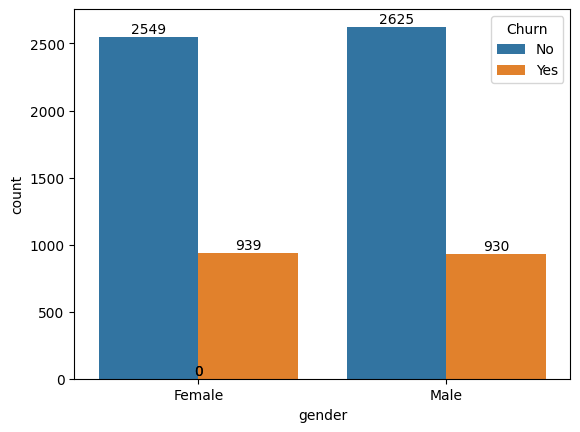

In [192]:
sns.countplot(x=df['gender'], hue='Churn', data=df)

for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width() / 2,
             p.get_height() + 30,
             int(p.get_height()),
             ha='center')

plt.show()

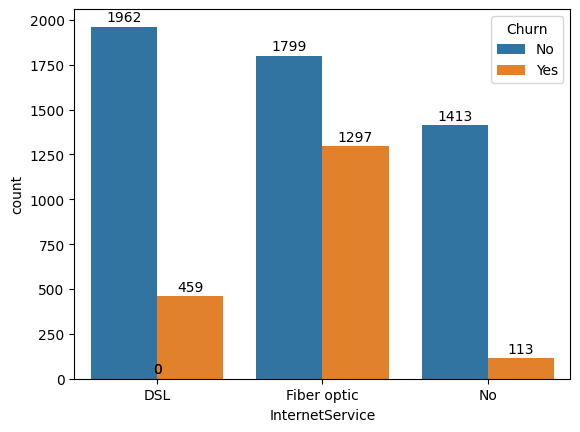

In [193]:
sns.countplot(x = 'InternetService', hue='Churn', data=df)

for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width() / 2,
             p.get_height() + 30,
             int(p.get_height()),
             ha='center')

plt.show()

In [194]:
df.InternetService.value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2421
No,1526


<Axes: xlabel='PhoneService', ylabel='count'>

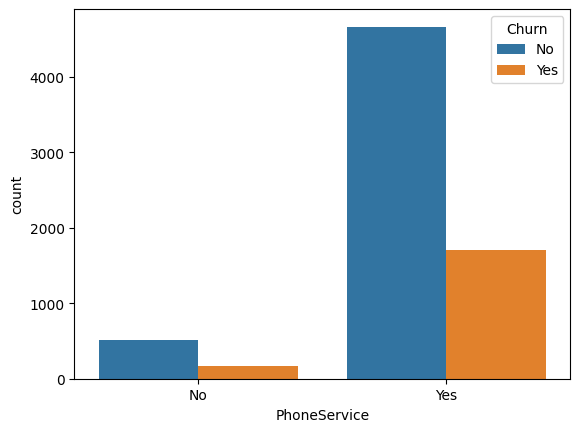

In [195]:
sns.countplot(x = 'PhoneService', hue='Churn', data=df)

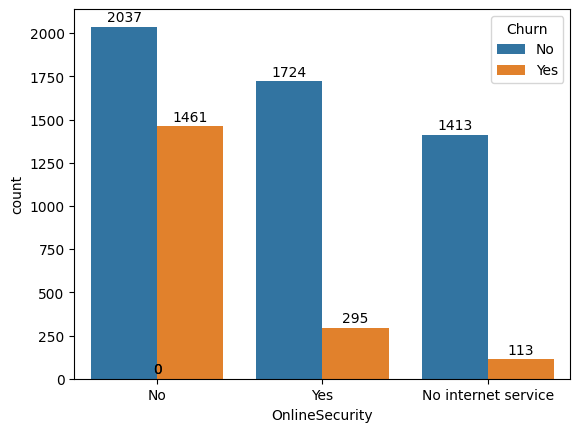

In [196]:
sns.countplot(x = 'OnlineSecurity',hue='Churn', data=df)

for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width() / 2,
             p.get_height() + 30,
             int(p.get_height()),
             ha='center')

plt.show()

In [197]:
df['OnlineSecurity'].value_counts()

,count
OnlineSecurity,
No,3498
Yes,2019
No internet service,1526


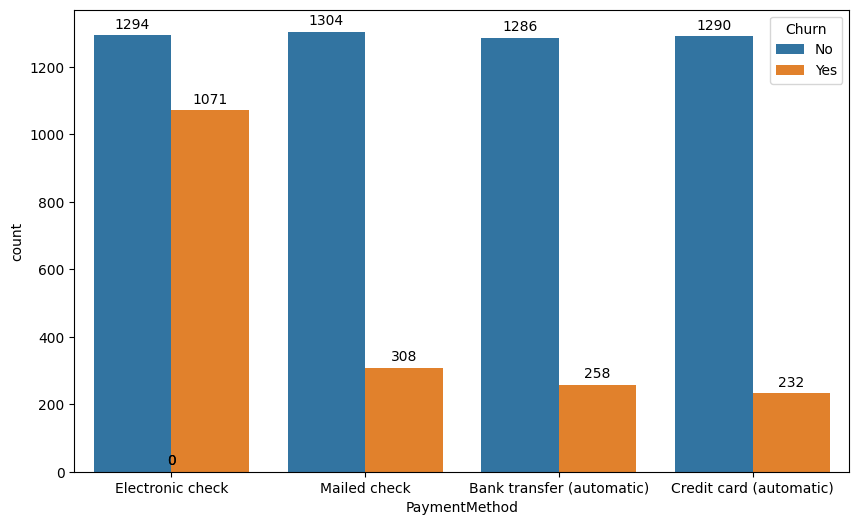

In [198]:
plt.subplots(figsize=(10,6))
sns.countplot(x = 'PaymentMethod', hue='Churn', data=df)

for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width() / 2,
             p.get_height() + 20,
             int(p.get_height()),
             ha='center')

plt.show()

In [199]:
df.select_dtypes(include = ['number']).corr()

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.01609,0.219856
tenure,0.016090,1.00000,0.247890
MonthlyCharges,0.219856,0.24789,1.000000


In [200]:
df.corr(numeric_only=True)  #shift+tab

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.01609,0.219856
tenure,0.016090,1.00000,0.247890
MonthlyCharges,0.219856,0.24789,1.000000


<Axes: >

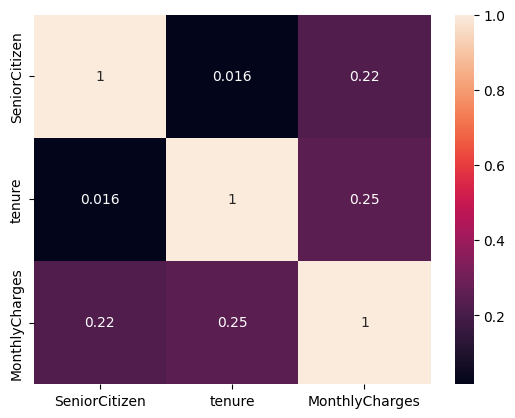

In [201]:
# ei dataset er jonn jode o heatmap dorkar ni but korlam.
sns.heatmap(df.corr(numeric_only=True), annot = True)

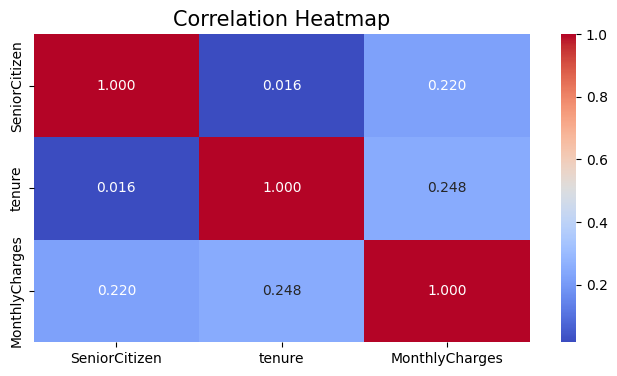

In [202]:
plt.figure(figsize=(8, 4))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,        # Annotate with correlation values
            fmt=".3f",         # Format the correlation values
            cmap='coolwarm',   # Choose a color map
            cbar=True)         # Display the color bar

plt.title('Correlation Heatmap', fontsize=15)
plt.show()

# **Preprocess The Dataset**

In [203]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [204]:
# customer Id not importance so , del customer id
df = df.drop('customerID', axis = 1)

In [205]:
df.shape

(7043, 20)

In [206]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **Encode the dataset**

In [207]:
#  some features in this dataset are catagorical to encoding korbo
from sklearn.preprocessing import LabelEncoder

In [208]:
label = LabelEncoder()
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [209]:
from pandas.core.dtypes.common import is_numeric_dtype

In [210]:
# now convert the string or object or text to numric value,  using encoding

for column in df.columns:
  if is_numeric_dtype(df[column]):
    continue
  else:
    df[column] = label.fit_transform(df[column])  # here is some limitation, full dataset ke transform korle data leckage hoy
  """The model is getting the exam papers before the exam.
  As a result, the model performs very well during training,
  but gives poor results when operating on new data."""

In [211]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925,1


# **seperate x, y**

In [212]:
x = df.drop('Churn', axis =1)   # seperate depente and indepent variable
y = df['Churn']  # churn is class

In [213]:
x.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925


In [214]:
x.shape

(7043, 19)

In [215]:
y.head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [216]:
y.shape

(7043,)

In [217]:
y.value_counts()  # check dataset are balance or imblanced by class(y/n)

,count
Churn,
0,5174
1,1869


In [218]:
# now check percentage wise to implance class(y/n)
not_churned = (5174/(5174+1869)) * 100
churned = (1869/(5174+1869)) * 100

print('Not churned {} percent of total people'.format(not_churned))
print('churned {} percent of total people'.format(churned))

Not churned 73.4630129206304 percent of total people
churned 26.536987079369588 percent of total people


# **Imbalanced Data Handling**

# 1. SMOTETomek: Synthetic Minority Oversampling Technique with Tomek Links

### SMOTETomek = SMOTE + Tomek Link

SMOTETomek is a hybrid technique that combines SMOTE (Synthetic Minority Over-sampling Technique) and Tomek Links to address the issue of imbalanced datasets.

## SMOTE (Synthetic Minority Over-sampling Technique)

1. **Purpose**: SMOTE aims to balance the dataset by increasing the number of minority class samples.

2. **Process**:
   - **Selection**: For each minority class sample, k-nearest neighbors are identified.
   - **Synthetic Sample Generation**: New synthetic samples are created by interpolating between the selected minority class sample and its k-nearest neighbors. This is done by taking a random point along the line segment between the two samples in feature space.
   - **Repetition**: This process is repeated until the minority class is sufficiently oversampled to balance the dataset.

## Tomek Links

1. **Purpose**: Tomek Links aim to clean the dataset by removing samples that are too close to each other and belong to different classes. This helps in reducing the overlap between classes and enhances the decision boundary.

2. **Process**:
   - **Identification of Tomek Links**: A pair of samples (one from the minority class and one from the majority class) are identified as a Tomek Link if they are each other’s nearest neighbors.
   - **Removal**: The identified Tomek Links are then removed from the dataset, which helps in making the classes more distinct.

## SMOTETomek

SMOTETomek combines the strengths of both SMOTE and Tomek Links to create a more balanced and cleaner dataset.

### Step-by-Step Process:
1. **SMOTE Application**: First, SMOTE is applied to the dataset to oversample the minority class by generating synthetic samples.
2. **Tomek Links Removal**: Next, Tomek Links are applied to the newly created dataset (including the synthetic samples) to remove samples that are too close to each other and belong to different classes.

### Outcome:
- The dataset becomes more balanced with an increased number of minority class samples due to SMOTE.
- The dataset also becomes cleaner with reduced overlap between classes due to the removal of Tomek Links, leading to potentially better performance of machine learning algorithms.

### Benefits of SMOTETomek
- **Balanced Dataset**: By oversampling the minority class, SMOTETomek ensures that the dataset is balanced, which helps in improving the performance of machine learning models.
- **Reduced Overlap**: By removing Tomek Links, it reduces the overlap between classes, which can enhance the model’s ability to discriminate between classes.
- **Improved Decision Boundaries**: The combined effect of SMOTE and Tomek Links can lead to cleaner decision boundaries and better generalization of the model.

## Example Workflow

### Original Dataset:
- Minority class: 100 samples
- Majority class: 1000 samples

### After SMOTE:
- Synthetic samples added to minority class: 900 samples
- Total samples for minority class: 100 + 900 = 1000 samples

### After Tomek Links:
- Some samples from both classes (that form Tomek Links) are removed.
- Final dataset: Balanced and cleaner.

`Note:` The exact final shape of the dataset after applying SMOTETomek is not fixed and can vary depending on the specific characteristics of the dataset and how many Tomek Links are identified and removed.

## Practical Implementation in Python (using `imblearn` library)

```python
from imblearn.combine import SMOTETomek
from collections import Counter
from sklearn.datasets import make_classification

# Generate an imbalanced dataset
X, y = make_classification(n_classes=2, class_sep=2, weights=[0.1, 0.9],
                           n_informative=3, n_redundant=1, flip_y=0,
                           n_features=20, n_clusters_per_class=1,
                           n_samples=1000, random_state=10)

print('Original dataset shape %s' % Counter(y))

# Apply SMOTETomek
smt = SMOTETomek(random_state=42)
X_res, y_res = smt.fit_resample(X, y)

print('Resampled dataset shape %s' % Counter(y_res))


# **Practical Example**

In [219]:
#!pip install imblearn

In [220]:
from imblearn.combine import SMOTETomek

In [221]:
sm = SMOTETomek(random_state = 42)

In [222]:
y.value_counts()  # before sampling

,count
Churn,
0,5174
1,1869


In [223]:
X, Y = sm.fit_resample(x, y)

In [224]:
X.shape

(9610, 19)

In [225]:
Y.value_counts()

,count
Churn,
0,4805
1,4805


In [226]:
Y.shape

(9610,)

In [227]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925


# Near Miss for Under-Sampling

## What is Near Miss?

Near Miss is a technique for under-sampling the majority class to balance class distribution in an imbalanced dataset. The key idea is to select samples from the majority class that are closest to the minority class samples.

## Near Miss Variants

1. **Near Miss-1**:
   - Select majority class samples with the smallest average distance to the k-nearest minority class samples.
   
2. **Near Miss-2**:
   - Select majority class samples with the smallest average distance to the k-farthest minority class samples.

3. **Near Miss-3**:
   - Select majority class samples such that each selected sample is the closest to one or more minority class samples.

## Practical Implementation in Python (using `imblearn` library)

### Example Workflow

#### Original Dataset:
- Minority class: 100 samples
- Majority class: 1000 samples

#### After Applying Near Miss:
- The number of majority class samples is reduced while preserving the boundary between the classes.

### Python Code Example

```python
from imblearn.under_sampling import NearMiss
from collections import Counter
from sklearn.datasets import make_classification

# Generate an imbalanced dataset
X, y = make_classification(n_classes=2, class_sep=2, weights=[0.1, 0.9],
                           n_informative=3, n_redundant=1, flip_y=0,
                           n_features=20, n_clusters_per_class=1,
                           n_samples=1000, random_state=10)

print('Original dataset shape %s' % Counter(y))

# Apply Near Miss
nm = NearMiss(version=1)  # You can change version to 1, 2, or 3
X_res, y_res = nm.fit_resample(X, y)

print('Resampled dataset shape %s' % Counter(y_res))


# **Practical Example**

In [228]:
df.Churn.value_counts()

,count
Churn,
0,5174
1,1869


In [229]:
from imblearn.under_sampling import NearMiss
print("x এর আকার:", x.shape)
print("y এর আকার:", y.shape)

x এর আকার: (7043, 19)
y এর আকার: (7043,)


In [230]:
NearMiss_obj = NearMiss()
new_x , new_y = NearMiss_obj.fit_resample(x,y)

In [231]:
x.shape

(7043, 19)

In [232]:
new_y.shape

(3738,)

In [233]:
new_x.shape

(3738, 19)

In [235]:
y.value_counts()

,count
Churn,
0,5174
1,1869


In [236]:
new_y.value_counts()

,count
Churn,
0,1869
1,1869


# Random Oversampling

## What is Random Oversampling?

Random Oversampling is a technique used to balance an imbalanced dataset by increasing the number of minority class samples. This is achieved by randomly duplicating existing samples from the minority class until the desired class balance is achieved.

## Process of Random Oversampling

1. **Selection**: Randomly select samples from the minority class with replacement.
2. **Duplication**: Add the selected samples to the original dataset.
3. **Repetition**: Repeat the process until the minority class has the same number of samples as the majority class.

## Advantages

- **Simplicity**: Random Oversampling is simple and easy to implement.
- **Effectiveness**: It can effectively balance the dataset by increasing the number of minority class samples.

## Disadvantages

- **Overfitting**: Randomly duplicating samples can lead to overfitting, as the model may learn from repeated samples.
- **Increased Data Size**: The dataset size increases, which can lead to longer training times.

## Practical Implementation in Python (using `imblearn` library)

### Example Workflow

#### Original Dataset:
- Minority class: 100 samples
- Majority class: 1000 samples

#### After Applying Random Oversampling:
- The number of minority class samples is increased to match the majority class.
- The dataset becomes balanced with an equal number of samples in both classes.



# **Practical Example**

In [237]:
df2.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [238]:
df2.Churn.value_counts()

,count
Churn,
No,5174
Yes,1869


In [240]:
from imblearn.over_sampling import RandomOverSampler
over = RandomOverSampler(random_state=1)
x_new , y_new = over.fit_resample(x,y)

In [241]:
x_new.shape

(10348, 19)

In [242]:
10348/2

5174.0

In [243]:
y_new.shape

(10348,)

# Without sampling

In [244]:
x.shape

(7043, 19)

In [245]:
x.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925


In [247]:
from sklearn.model_selection import train_test_split
xtrain1, xtest1, ytrain1, ytest1 = train_test_split(x, y, train_size=.75,random_state=42)

In [248]:
from sklearn.linear_model import LogisticRegression
Clf = LogisticRegression()

In [249]:
Clf.fit(xtrain1, ytrain1)

LogisticRegression()

In [250]:
Clf.score(xtest1,ytest1) # imbalanced old data

0.807495741056218

In [251]:
Clf.score(xtrain1, ytrain1)  #training score

0.8000757288905718

# XGBoost Classifier (Extra)

In [252]:
#!pip install xgboost

In [254]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(xtrain1, ytrain1)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [255]:
xgb.score(xtest1, ytest1) # After sampling

0.7904599659284497

# After sampling

# Logistic Regression

In [256]:
xtrain2, xtest2, ytrain2, ytest2 = train_test_split(X, Y, train_size=.75,random_state=42) #Synthetic Minority Oversampling Technique with Tomek Links

In [257]:
Clf.fit(xtrain2, ytrain2)

LogisticRegression()

In [258]:
Clf.score(xtest2, ytest2)

0.8206408655846859

In [259]:
Clf.score(xtrain2, ytrain2)

0.8164284723185792

# Xgboost (Extra)

In [260]:
xgb.fit(xtrain2, ytrain2)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [261]:
xgb.score(xtest2, ytest2)

0.8680815647107782